In [39]:
# ============================================
# 1. БАЗОВЫЕ БИБЛИОТЕКИ
# ============================================
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 2. ВИЗУАЛИЗАЦИЯ
# ============================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline

# ============================================
# 3. ПРЕДОБРАБОТКА
# ============================================
from sklearn.preprocessing import LabelEncoder

# ============================================
# 4. МОДЕЛЬ
# ============================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

# ============================================
# 5. ОЦЕНКА
# ============================================
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve

# ============================================
# 6. BASELINE СРАВНЕНИЕ
# ============================================
from sklearn.linear_model import LogisticRegression

# ============================================
# 7. НАСТРОЙКИ ОТОБРАЖЕНИЯ
# ============================================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [40]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')


In [41]:
print("=== ПРОПУСКИ В TRAIN ===")
missing_train = pd.DataFrame({
    'Пропусков': train_df.isnull().sum(),
    'Процент %': (train_df.isnull().sum() / len(train_df) * 100).round(2)
}).sort_values('Процент %', ascending=False)

print(missing_train[missing_train['Пропусков'] > 0])

print("\n=== ПРОПУСКИ В TEST ===")
missing_test = pd.DataFrame({
    'Пропусков': test_df.isnull().sum(),
    'Процент %': (test_df.isnull().sum() / len(test_df) * 100).round(2)
}).sort_values('Процент %', ascending=False)

print(missing_test[missing_test['Пропусков'] > 0])

=== ПРОПУСКИ В TRAIN ===
          Пропусков  Процент %
Cabin           687      77.10
Age             177      19.87
Embarked          2       0.22

=== ПРОПУСКИ В TEST ===
       Пропусков  Процент %
Cabin        327      78.23
Age           86      20.57
Fare           1       0.24


In [42]:
test_passenger_ids = test_df['PassengerId'].copy()

# Сохраняем целевую переменную:
y_train = train_df['Survived'].copy()

# Объединяем для единой предобработки:
full_df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Full: {full_df.shape}")

Train: (891, 12)
Test: (418, 11)
Full: (1309, 12)


In [43]:
full_df['Title'] = full_df['Name'].str.extract(r'([A-Za-z]+)\.')

# Редкие титулы объединяем:
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don',
               'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
full_df['Title'] = full_df['Title'].replace(rare_titles, 'Rare')
full_df['Title'] = full_df['Title'].replace({'Mlle': 'Miss',
                                              'Ms': 'Miss',
                                              'Mme': 'Mrs'})

# Маппинг вместо LabelEncoder:
title_map = {
    'Mr': 1,
    'Miss': 2,
    'Mrs': 3,
    'Master': 4,
    'Rare': 5
}
full_df['Title'] = full_df['Title'].map(title_map)

print(full_df['Title'].value_counts())
print(f"Пропуски в Title: {full_df['Title'].isnull().sum()}")

Title
1    757
2    264
3    198
4     61
5     29
Name: count, dtype: int64
Пропуски в Title: 0


In [44]:
# 2. Размер семьи:
full_df['FamilySize'] = full_df['SibSp'] + full_df['Parch'] + 1
# 3. Один или нет:
full_df['IsAlone'] = (full_df['FamilySize'] == 1).astype(int)
# 4. Наличие каюты:
full_df['Has_Cabin'] = full_df['Cabin'].notna().astype(int)
# 5. Палуба из номера каюты:
full_df['Deck'] = full_df['Cabin'].str.extract(r'([A-Za-z])')
full_df['Deck'] = full_df['Deck'].fillna('Unknown')

print("=== БАЗОВЫЕ ПРИЗНАКИ ДОБАВЛЕНЫ ===")
print(f"FamilySize: мин={full_df['FamilySize'].min()}, "
      f"макс={full_df['FamilySize'].max()}, "
      f"среднее={full_df['FamilySize'].mean():.1f}")
print(f"IsAlone:    одиночек={full_df['IsAlone'].sum()} "
      f"({full_df['IsAlone'].mean()*100:.1f}%)")
print(f"Has_Cabin:  с каютой={full_df['Has_Cabin'].sum()} "
      f"({full_df['Has_Cabin'].mean()*100:.1f}%), "
      f"без каюты={(full_df['Has_Cabin']==0).sum()}")
print(f"Deck:       уникальных палуб={full_df['Deck'].nunique()}, "
      f"Unknown={( full_df['Deck']=='Unknown').sum()}")
print(f"\nВсего колонок после: {full_df.shape[1]}")

=== БАЗОВЫЕ ПРИЗНАКИ ДОБАВЛЕНЫ ===
FamilySize: мин=1, макс=11, среднее=1.9
IsAlone:    одиночек=790 (60.4%)
Has_Cabin:  с каютой=295 (22.5%), без каюты=1014
Deck:       уникальных палуб=9, Unknown=1014

Всего колонок после: 17


In [45]:
# train часть = первые 891 строк
train_part = full_df[:891]

# Embarked — мода только по train:
embarked_mode = train_part['Embarked'].mode()[0]
full_df['Embarked'] = full_df['Embarked'].fillna(embarked_mode)
print(f"Embarked заполнен: {embarked_mode}")

# Fare — медиана по Pclass только по train:
fare_median_by_class = train_part.groupby('Pclass')['Fare'].median()
print(f"\nМедиана Fare по классам:\n{fare_median_by_class}")

def fill_fare(row):
    if pd.isna(row['Fare']):
        return fare_median_by_class[row['Pclass']]
    return row['Fare']

full_df['Fare'] = full_df.apply(fill_fare, axis=1)

# Age — медиана по Title + Pclass только по train:
age_median = train_part.groupby(['Title', 'Pclass'])['Age'].median()
print(f"\nМедиана Age по Title+Pclass:\n{age_median}")

def fill_age(row):
    if pd.isna(row['Age']):
        try:
            return age_median[row['Title'], row['Pclass']]
        except KeyError:
            return train_part['Age'].median()
    return row['Age']

full_df['Age'] = full_df.apply(fill_age, axis=1)

# Проверка:
print("\nПропуски после заполнения:")
print(full_df[['Age', 'Embarked', 'Fare']].isnull().sum())

Embarked заполнен: S

Медиана Fare по классам:
Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64

Медиана Age по Title+Pclass:
Title  Pclass
1      1         40.0
       2         31.0
       3         26.0
2      1         30.0
       2         24.0
       3         18.0
3      1         40.0
       2         32.0
       3         31.0
4      1          4.0
       2          1.0
       3          4.0
5      1         48.5
       2         46.5
Name: Age, dtype: float64

Пропуски после заполнения:
Age         0
Embarked    0
Fare        0
dtype: int64


In [46]:
# ============================================
# 5.1 ДОПОЛНИТЕЛЬНЫЕ ПРИЗНАКИ
# (после заполнения пропусков!)
# ============================================

# Age * Pclass взаимодействие:
full_df['Age_Pclass'] = full_df['Age'] * full_df['Pclass']

# Fare на человека:
full_df['Fare_per_person'] = full_df['Fare'] / full_df['FamilySize']

# Категория возраста:
full_df['Age_Group'] = pd.cut(
    full_df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=[0, 1, 2, 3, 4]
).astype(int)

# Категория размера семьи:
def family_category(size):
    if size == 1:
        return 0  # одиночка
    elif size <= 4:
        return 1  # маленькая семья
    else:
        return 2  # большая семья

full_df['Family_Category'] = full_df['FamilySize'].apply(family_category)

# ============================================
# FAMILY SURVIVAL
# ============================================

# Шаг 1 — извлекаем фамилию:
full_df['Last_Name'] = full_df['Name'].apply(
    lambda x: x.split(',')[0].strip()
)

# Шаг 2 — дефолтное значение 0.5 (неизвестно):
DEFAULT_SURVIVAL = 0.5
full_df['Family_Survival'] = DEFAULT_SURVIVAL

# Шаг 3 — по фамилии + Fare (только train!):
train_part = full_df[:891]

for _, grp_df in train_part.groupby(['Last_Name', 'Fare']):
    if len(grp_df) != 1:  # семья > 1 человека
        for ind, row in grp_df.iterrows():
            # смотрим на ДРУГИХ членов семьи:
            others = grp_df.drop(ind)
            smax = others['Survived'].max()
            smin = others['Survived'].min()
            passID = row['PassengerId']

            if smax == 1.0:
                full_df.loc[
                    full_df['PassengerId'] == passID,
                    'Family_Survival'
                ] = 1
            elif smin == 0.0:
                full_df.loc[
                    full_df['PassengerId'] == passID,
                    'Family_Survival'
                ] = 0

# Шаг 4 — по номеру билета:
for _, grp_df in train_part.groupby('Ticket'):
    if len(grp_df) != 1:
        for ind, row in grp_df.iterrows():
            # обновляем только если ещё неизвестно (0.5):
            if row['Family_Survival'] == DEFAULT_SURVIVAL:
                others = grp_df.drop(ind)
                smax = others['Survived'].max()
                smin = others['Survived'].min()
                passID = row['PassengerId']

                if smax == 1.0:
                    full_df.loc[
                        full_df['PassengerId'] == passID,
                        'Family_Survival'
                    ] = 1
                elif smin == 0.0:
                    full_df.loc[
                        full_df['PassengerId'] == passID,
                        'Family_Survival'
                    ] = 0

print("=== НОВЫЕ ПРИЗНАКИ ДОБАВЛЕНЫ ===")
print(f"\nFamily_Survival распределение:")
print(full_df['Family_Survival'].value_counts())
print(f"\nПроцент известных (не 0.5): "
      f"{(full_df['Family_Survival'] != 0.5).mean()*100:.1f}%")
print(f"\nВсего колонок: {full_df.shape[1]}")
print(f"\nВсе признаки:")
print(full_df.columns.tolist())

=== НОВЫЕ ПРИЗНАКИ ДОБАВЛЕНЫ ===

Family_Survival распределение:
Family_Survival
0.5    934
1.0    199
0.0    176
Name: count, dtype: int64

Процент известных (не 0.5): 28.6%

Всего колонок: 23

Все признаки:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Has_Cabin', 'Deck', 'Age_Pclass', 'Fare_per_person', 'Age_Group', 'Family_Category', 'Last_Name', 'Family_Survival']


In [47]:
# ============================================
# 5.2 PREDICT DECK для Unknown
# ============================================

def predict_deck(row):
    if row['Deck'] != 'Unknown':
        return row['Deck']

    if row['Pclass'] == 1:
        if row['Embarked'] == 'C' and row['Fare'] > 50:
            return 'B'
        elif row['Fare'] > 70:
            return 'C'
        else:
            return 'C'
    elif row['Pclass'] == 2:
        if row['FamilySize'] > 4:
            return 'F'
        else:
            return 'E'
    else:  # Pclass == 3
        if row['Embarked'] == 'Q':
            return 'G'
        elif row['FamilySize'] > 4:
            return 'G'
        else:
            return 'F'

full_df['Deck'] = full_df.apply(predict_deck, axis=1)

print("=== DECK ПОСЛЕ PREDICT ===")
print(full_df['Deck'].value_counts())
print(f"Unknown осталось: {(full_df['Deck'] == 'Unknown').sum()}")

=== DECK ПОСЛЕ PREDICT ===
Deck
F    541
E    293
G    180
C    144
B     82
D     46
A     22
T      1
Name: count, dtype: int64
Unknown осталось: 0


In [48]:
# ============================================
# 5.3 CABIN SURVIVAL RATE (Target Encoding)
# ============================================

train_part = full_df[:891]

# Выживаемость по Pclass + Deck (только train!):
survival_rate = train_part.groupby(
    ['Pclass', 'Deck']
)['Survived'].mean()

# Запасное — среднее по палубе:
survival_rate_deck = train_part.groupby(
    'Deck'
)['Survived'].mean()

print("=== ВЫЖИВАЕМОСТЬ ПО КЛАССУ И ПАЛУБЕ ===")
print(survival_rate.round(2))

def get_survival_rate(row):
    key = (row['Pclass'], row['Deck'])
    if key in survival_rate.index:
        return survival_rate[key]
    elif row['Deck'] in survival_rate_deck.index:
        return survival_rate_deck[row['Deck']]
    else:
        return train_part['Survived'].mean()

full_df['Cabin_Survival_Rate'] = full_df.apply(
    get_survival_rate, axis=1
)

print(f"\nУникальных значений: "
      f"{full_df['Cabin_Survival_Rate'].nunique()}")
print(f"Пропуски: "
      f"{full_df['Cabin_Survival_Rate'].isnull().sum()}")
print(full_df['Cabin_Survival_Rate'].value_counts().round(2))

=== ВЫЖИВАЕМОСТЬ ПО КЛАССУ И ПАЛУБЕ ===
Pclass  Deck
1       A       0.47
        B       0.72
        C       0.53
        D       0.76
        E       0.72
        T       0.00
2       D       0.75
        E       0.44
        F       0.90
3       E       1.00
        F       0.23
        G       0.27
Name: Survived, dtype: float64

Уникальных значений: 12
Пропуски: 0
Cabin_Survival_Rate
0.228022    526
0.441176    256
0.266129    180
0.534091    144
0.724138     82
0.758621     40
0.720000     34
0.466667     22
0.900000     15
0.750000      6
1.000000      3
0.000000      1
Name: count, dtype: int64


In [49]:
le = LabelEncoder()

# Только Sex и Embarked:
categorical_cols = ['Sex', 'Embarked']

for col in categorical_cols:
    full_df[col] = le.fit_transform(
        full_df[col].astype(str)
    )
    print(f"{col}: {full_df[col].unique()}")

print("\nТипы данных после кодирования:")
print(full_df[categorical_cols].dtypes)

Sex: [1 0]
Embarked: [2 0 1]

Типы данных после кодирования:
Sex         int64
Embarked    int64
dtype: object


In [50]:
# Проверка что нет NaN в новых признаках:
print(full_df[[
    'Age_Pclass',
    'Fare_per_person',
    'Age_Group',
    'Family_Category',
    'Cabin_Survival_Rate'
]].isnull().sum())

Age_Pclass             0
Fare_per_person        0
Age_Group              0
Family_Category        0
Cabin_Survival_Rate    0
dtype: int64


In [51]:
drop_cols = ['PassengerId', 'Name', 'Ticket',
             'Cabin', 'SibSp', 'Parch',
             'IsAlone',
             'Age_Group',
             'Has_Cabin',
             'Deck',
             'FamilySize',   
             'Fare', 'Last_Name']    

full_df = full_df.drop(columns=drop_cols)

print("=== ФИНАЛЬНЫЕ ПРИЗНАКИ ===")
print(full_df.columns.tolist())
print(f"\nРазмер: {full_df.shape}")
print(f"Признаков для модели: {full_df.shape[1] - 1}")

=== ФИНАЛЬНЫЕ ПРИЗНАКИ ===
['Survived', 'Pclass', 'Sex', 'Age', 'Embarked', 'Title', 'Age_Pclass', 'Fare_per_person', 'Family_Category', 'Family_Survival', 'Cabin_Survival_Rate']

Размер: (1309, 11)
Признаков для модели: 10


In [52]:
# Разделяем обратно на train и test:
X_train = full_df[:891].drop(columns=['Survived'])
X_test = full_df[891:].drop(columns=['Survived'])

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")

# Финальная проверка пропусков:
print("\nПропуски в X_train:")
print(X_train.isnull().sum())
print("\nПропуски в X_test:")
print(X_test.isnull().sum())

X_train: (891, 10)
X_test: (418, 10)
y_train: (891,)

Пропуски в X_train:
Pclass                 0
Sex                    0
Age                    0
Embarked               0
Title                  0
Age_Pclass             0
Fare_per_person        0
Family_Category        0
Family_Survival        0
Cabin_Survival_Rate    0
dtype: int64

Пропуски в X_test:
Pclass                 0
Sex                    0
Age                    0
Embarked               0
Title                  0
Age_Pclass             0
Fare_per_person        0
Family_Category        0
Family_Survival        0
Cabin_Survival_Rate    0
dtype: int64


In [53]:
# ============================================
# 8. ПОДГОТОВКА — SPLIT 80/20
# ============================================
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train  # сохраняет баланс классов!
)

print(f"X_tr:  {X_tr.shape}")
print(f"X_val: {X_val.shape}")
print(f"Выживших в tr:  {y_tr.mean():.2%}")
print(f"Выживших в val: {y_val.mean():.2%}")

X_tr:  (712, 10)
X_val: (179, 10)
Выживших в tr:  38.34%
Выживших в val: 38.55%


In [54]:
# ============================================
# 9. GRIDSEARCH на X_tr (5 фолдов)
# ============================================

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [3, 4, 5],
    'min_samples_split': [4, 6, 8],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tr, y_tr)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"CV score (train): {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Лучшие параметры: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 300}
CV score (train): 0.858


In [56]:
# ============================================
# 10. ОЦЕНКА НА ВАЛИДАЦИИ
# ============================================

best_model = grid_search.best_estimator_
val_predictions = best_model.predict(X_val)
val_score = best_model.score(X_val, y_val)
train_score = best_model.score(X_tr, y_tr)

print("=== РЕЗУЛЬТАТЫ ===")
print(f"Train accuracy: {train_score:.3f}")
print(f"Val accuracy:   {val_score:.3f}")
print(f"Разрыв:         {train_score - val_score:.3f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_val, val_predictions,
    target_names=['Погиб', 'Выжил']
))

=== РЕЗУЛЬТАТЫ ===
Train accuracy: 0.868
Val accuracy:   0.810
Разрыв:         0.058

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       Погиб       0.81      0.90      0.85       110
       Выжил       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



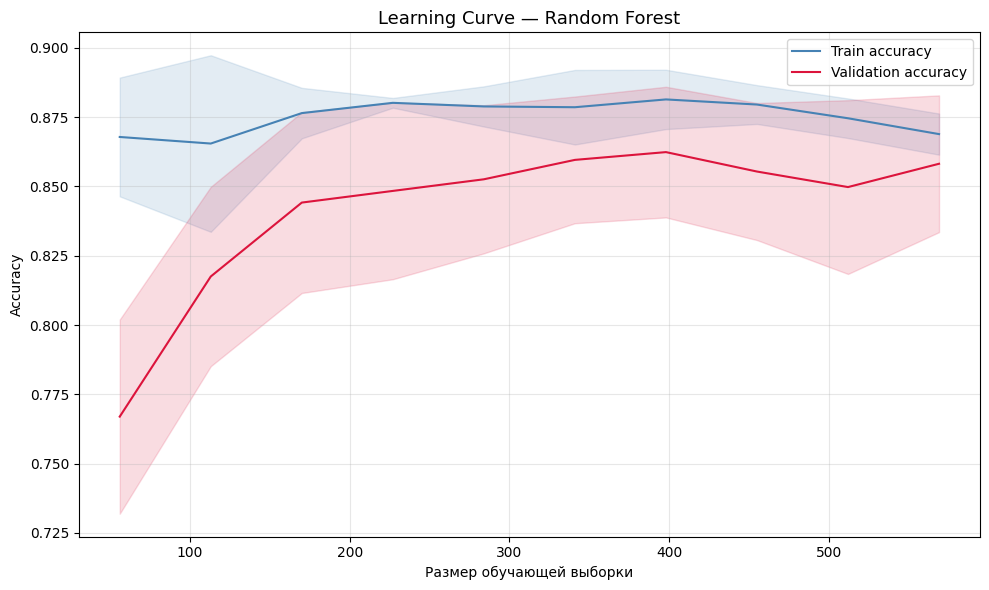

Финальный train: 0.869
Финальный val:   0.858
Разрыв:          0.011


In [57]:
# ============================================
# 12. LEARNING CURVE
# ============================================

train_sizes, train_scores, val_scores = learning_curve(
    grid_search.best_estimator_,
    X_tr, y_tr,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean,
        color='steelblue', label='Train accuracy')
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15, color='steelblue'
)

ax.plot(train_sizes, val_mean,
        color='crimson', label='Validation accuracy')
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15, color='crimson'
)

ax.set_title('Learning Curve — Random Forest',
             fontsize=13)
ax.set_xlabel('Размер обучающей выборки')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Финальный train: {train_mean[-1]:.3f}")
print(f"Финальный val:   {val_mean[-1]:.3f}")
print(f"Разрыв:          {train_mean[-1] - val_mean[-1]:.3f}")

In [58]:
# ============================================
# 13. ФИНАЛЬНОЕ ОБУЧЕНИЕ НА ВСЁМ TRAIN
# ============================================

# Переобучаем на ВСЁМ X_train (не только X_tr!):
best_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=3, min_samples_leaf=3, min_samples_split=8,
                       n_estimators=300, random_state=42)

In [60]:
# ============================================
# 10. SEED AVERAGE + SUBMISSION
# ============================================

predictions_list = []
for seed in range(50):
    model = RandomForestClassifier(
        **grid_search.best_params_,
        random_state=seed
    )
    model.fit(X_train, y_train)
    predictions_list.append(
        model.predict_proba(X_test)[:,1]
    )

final_predictions = np.mean(predictions_list, axis=0)
predictions = (final_predictions >= 0.5).astype(int)

# Создаём и проверяем submission:
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions.astype(int)
})

print("=== ПРОВЕРКА SUBMISSION ===")
print(f"Строк:            {len(submission)}")
print(f"Пропуски:         {submission.isnull().sum().sum()}")
print(f"Уникальные:       {submission['Survived'].unique()}")
print(f"Выживших:         {predictions.sum()}")
print(f"Не выживших:      {(predictions == 0).sum()}")

# Сохраняем:
submission.to_csv('submission.csv', index=False)
print("\n✅ submission.csv готов!")

=== ПРОВЕРКА SUBMISSION ===
Строк:            418
Пропуски:         0
Уникальные:       [0 1]
Выживших:         156
Не выживших:      262

✅ submission.csv готов!


In [61]:
# Проверь что формат совпадает:
gender_submission = pd.read_csv('data/gender_submission.csv')
print("Наш submission:")
print(submission.head(3))
print("\ngender_submission:")
print(gender_submission.head(3))

Наш submission:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0

gender_submission:
   PassengerId  Survived
0          892         0
1          893         1
2          894         0


In [62]:

import joblib

# Сохраняем обученную модель:
joblib.dump(best_model, 'best_model.pkl')
print("✅ Модель сохранена!")

# Проверяем что сохранилась:
loaded_model = joblib.load('best_model.pkl')
test_predictions = loaded_model.predict(X_test)
print(f"✅ Модель загружена и работает!")
print(f"Предсказаний: {len(test_predictions)}")

✅ Модель сохранена!
✅ Модель загружена и работает!
Предсказаний: 418
